In [ ]:
import gymnasium as gym
from gymnasium import spaces
from gymnasium.wrappers import FrameStackObservation, FlattenObservation
import numpy as np
import random
import math

# ==========================================
# THE NON-HOLONOMIC ENVIRONMENT
# ==========================================
class Vanguard2D(gym.Env):
    metadata = {"render_modes": ["human"], "render_fps": 30}

    def __init__(self, render_mode=None):
        super(Vanguard2D, self).__init__()

        self.target_dist = 0.5
        self.dt = 0.1

        self.max_lin_accel = 6.0

        self.render_mode = render_mode

        # ACTION SPACE FIXED TO 1D: Only Linear Acceleration
        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(1,), dtype=np.float32)

        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(9,), dtype=np.float32)

        self.p_pos = np.array([0.0, 0.0], dtype=np.float32)
        self.p_vel = np.array([0.0, 0.0], dtype=np.float32)
        self.p_theta = 0.0
        self.p_omega = 0.0
        self.p_start_theta = 0.0  # Added to track heading before a turn

        # Person State Variables
        self.p_speed = 0.0
        self.p_state = 0
        self.p_turn_timer = 0
        self.p_target_speed = 0.0
        self.turn_signal = 0.0

        self.s_pos = np.array([0.0, 0.0], dtype=np.float32)
        self.s_vel = 0.0
        self.s_theta = 0.0
        self.s_omega = 0.0

        # Hierarchical Control Flags
        self.cart_macro_timer = 0
        self.cart_macro_dir = 0
        self.correction_active = False

        self.step_count = 0

    def _to_ego_frame(self, global_vec, ego_theta):
        c, s = math.cos(ego_theta), math.sin(ego_theta)
        x_local = global_vec[0] * c + global_vec[1] * s
        y_local = -global_vec[0] * s + global_vec[1] * c
        return np.array([x_local, y_local], dtype=np.float32)

    def _get_obs(self):
        # We use the exact true states for the observation space
        dir_vec = np.array([math.cos(self.p_theta), math.sin(self.p_theta)])
        ideal_pos = self.p_pos + (dir_vec * self.target_dist)

        global_error = ideal_pos - self.s_pos
        local_error = self._to_ego_frame(global_error, self.s_theta)
        local_p_vel = self._to_ego_frame(self.p_vel, self.s_theta)
        rel_theta = (self.p_theta - self.s_theta + math.pi) % (2*math.pi) - math.pi

        obs = np.array([
            local_error[0], local_error[1],
            self.s_vel, self.s_omega,
            local_p_vel[0], local_p_vel[1],
            rel_theta, self.p_omega,
            self.turn_signal
        ], dtype=np.float32)

        return obs

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.p_pos = np.array([0.0, 0.0])
        self.p_theta = random.uniform(0, 2 * math.pi)
        self.p_start_theta = self.p_theta
        self.p_omega = 0.0
        self.p_speed = 1.2
        self.p_state = 0
        self.turn_signal = 0.0

        self.cart_macro_timer = 0
        self.correction_active = False

        self.p_vel = np.array([math.cos(self.p_theta) * self.p_speed, math.sin(self.p_theta) * self.p_speed])

        dir_vec = np.array([math.cos(self.p_theta), math.sin(self.p_theta)])
        self.s_pos = self.p_pos + (dir_vec * self.target_dist)

        # Cart starts perfectly aligned with the person
        self.s_theta = self.p_theta
        self.s_vel = self.p_speed
        self.s_omega = 0.0

        self.step_count = 0
        return self._get_obs(), {}

    def step(self, action):
        self.step_count += 1

        # ==========================================
        # CART HIERARCHICAL CONTROL OVERRIDES
        # ==========================================

        # 1. Trigger macro if CV detects a new turn
        if self.turn_signal != 0 and self.cart_macro_timer == 0 and not self.correction_active:
            self.cart_macro_dir = self.turn_signal
            # 12 steps (1.2s) for Dive + 6 steps (0.6s) for Hook = 18 steps total
            self.cart_macro_timer = 18

        # 2. Execute the Clothoid Macro
        if self.cart_macro_timer > 0:
            if self.cart_macro_timer > 6:
                # Phase 1: Deep Dive
                self.s_vel = 1.31
                # Positive omega is Left turn, Negative omega is Right turn
                self.s_omega = (math.pi / 1.2) * self.cart_macro_dir
            else:
                # Phase 2: The Hook
                self.s_vel = 1.31
                self.s_omega = -(math.pi / 1.2) * self.cart_macro_dir

            self.cart_macro_timer -= 1

            # Transition to Correction Module when macro ends
            if self.cart_macro_timer == 0:
                self.correction_active = True

        # 3. Execute the Micro-Correction Module
        elif self.correction_active:
            p_speed_actual = np.linalg.norm(self.p_vel)

            # Calculate CTE (Lateral drift from person's true line)
            cte = -(self.s_pos[0] - self.p_pos[0]) * math.sin(self.p_theta) + \
                   (self.s_pos[1] - self.p_pos[1]) * math.cos(self.p_theta)

            # Calculate Heading Error
            heading_error = (self.s_theta - self.p_theta + math.pi) % (2 * math.pi) - math.pi

            # PD Control for Angular Velocity
            override_omega = -2.0 * heading_error - 1.5 * cte
            self.s_omega = np.clip(override_omega, -1.0, 1.0)

            # P-Controller Sprint for Linear Velocity to catch up
            ix = self.p_pos[0] + math.cos(self.p_theta) * self.target_dist
            iy = self.p_pos[1] + math.sin(self.p_theta) * self.target_dist
            forward_error = (ix - self.s_pos[0]) * math.cos(self.p_theta) + (iy - self.s_pos[1]) * math.sin(self.p_theta)

            override_vel = p_speed_actual + forward_error * 2.5
            self.s_vel = np.clip(override_vel, -3.0, 6.0)

            # Shut down correction if errors are within tight tolerances
            if abs(cte) < 0.05 and abs(heading_error) < 0.05:
                self.correction_active = False

        # 4. Standard RL Control (Strictly 1D)
        else:
            self.s_vel += (action[0] * self.max_lin_accel) * self.dt
            self.s_vel = np.clip(self.s_vel, -3.0, 6.0)

            # Strictly lock angular velocity to 0 so it maintains its current straight line
            self.s_omega = 0.0

        # --- NON-HOLONOMIC PHYSICS: Stroller ---
        self.s_theta += self.s_omega * self.dt
        self.s_theta = (self.s_theta + math.pi) % (2*math.pi) - math.pi

        self.s_pos[0] += self.s_vel * math.cos(self.s_theta) * self.dt
        self.s_pos[1] += self.s_vel * math.sin(self.s_theta) * self.dt

        # ==========================================
        # PERSON PHYSICS: GROCERY AISLE LOGIC
        # ==========================================
        if self.p_state == 0:
            self.turn_signal = 0.0
            self.p_omega = 0.0
            lin_accel_noise = random.uniform(-0.5, 0.5)
            self.p_speed = np.clip(self.p_speed + (lin_accel_noise * self.dt), 0.0, 1.8)

            # Guaranteed turn at step 40 for testing
            if self.step_count == 40:
                self.p_state = random.choice([1, 2]) # 1: Left, 2: Right
                self.p_target_speed = max(0.5, self.p_speed)
                self.p_speed = 0.0
                self.p_turn_timer = 5
                self.p_start_theta = self.p_theta  # Save the heading BEFORE the turn starts

        elif self.p_state in [1, 2]:
            # 1 (Left Turn) -> POSITIVE Omega. 2 (Right Turn) -> NEGATIVE Omega.
            self.turn_signal = 1.0 if self.p_state == 1 else -1.0
            self.p_speed = 0.0
            self.p_omega = ((math.pi / 2.0) / 0.5) * self.turn_signal
            self.p_theta += self.p_omega * self.dt
            self.p_turn_timer -= 1

            if self.p_turn_timer <= 0:
                self.p_state = 3
                self.p_omega = 0.0

                # Snap strictly relative to the starting angle to clear float drift
                target_offset = (math.pi / 2.0) * self.turn_signal
                self.p_theta = self.p_start_theta + target_offset
                self.p_theta = (self.p_theta + math.pi) % (2*math.pi) - math.pi

        elif self.p_state == 3:
            self.turn_signal = 0.0
            self.p_omega = 0.0
            self.p_speed += 1.5 * self.dt
            if self.p_speed >= self.p_target_speed:
                self.p_speed = self.p_target_speed
                self.p_state = 0

        self.p_vel = np.array([math.cos(self.p_theta) * self.p_speed, math.sin(self.p_theta) * self.p_speed])
        self.p_pos += self.p_vel * self.dt

        # --- Reward Calculation ---
        dir_vec = np.array([math.cos(self.p_theta), math.sin(self.p_theta)])
        true_ideal_pos = self.p_pos + (dir_vec * self.target_dist)

        dist_error = np.linalg.norm(self.s_pos - true_ideal_pos)

        reward = 10.0
        reward -= 3.0 * (dist_error ** 2)

        if self.cart_macro_timer == 0 and not self.correction_active:
            reward -= 0.05 * np.sum(action ** 2)

        terminated = False
        if np.linalg.norm(self.s_pos - self.p_pos) < 0.3:
            reward -= 50.0
            terminated = True
        if dist_error > 3.0:
            reward -= 100.0
            terminated = True

        truncated = (self.step_count > 500)

        return self._get_obs(), reward, terminated, truncated, {}

# --- Wrapper Helper ---
def make_vanguard_2d(render_mode=None):
    env = Vanguard2D(render_mode=render_mode)
    env = FrameStackObservation(env, stack_size=4)
    env = FlattenObservation(env)
    return env

In [ ]:
from stable_baselines3 import PPO
import os

# 1. Create the 2D Environment
env = make_vanguard_2d(render_mode=None)

# 2. Initialize PPO
model = PPO("MlpPolicy", env, verbose=1)

print("Starting 2D Grocery Aisle Training...")
print(f"Observation Space: {env.observation_space.shape}") # Should be (36,)

# 3. Train
# Because the hard part (turns) is now hardcoded, the RL agent
# should converge on the straight-line driving very quickly!
model.learn(total_timesteps=1000000)

print("Training Complete!")
model.save("vanguard_2d_aisle_ppo")

Streaming output truncated to the last 5000 lines.
|    n_updates            | 2610        |
|    policy_gradient_loss | -0.0026     |
|    std                  | 0.973       |
|    value_loss           | 2.08e+03    |
-----------------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 492         |
|    ep_rew_mean          | 3.11e+03    |
| time/                   |             |
|    fps                  | 718         |
|    iterations           | 263         |
|    time_elapsed         | 749         |
|    total_timesteps      | 538624      |
| train/                  |             |
|    approx_kl            | 0.006480775 |
|    clip_fraction        | 0.0519      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.39       |
|    explained_variance   | 0.976       |
|    learning_rate        | 0.0003      |
|    loss                 | 1.15e+03    |
|    n_updates           

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
import numpy as np
import time
import math

# 1. Load Environment & Model
env = make_vanguard_2d(render_mode=None)

# Uncomment the load line below if loading from a saved file:
# model = PPO.load("vanguard_2d_aisle_ppo")

obs, _ = env.reset()

p_trail_x, p_trail_y = [], []
s_trail_x, s_trail_y = [], []

print("Starting Hierarchical Vanguard Simulation...")
time.sleep(2)

try:
    for step in range(300):

        # ---------------------------------------------------------
        # ACTION SELECTION
        # ---------------------------------------------------------
        try:
            action, _ = model.predict(obs, deterministic=True)
        except NameError:
            # FIX: If model isn't trained yet, provide slight forward gas
            # so the cart doesn't fall behind and trigger the 3.0m termination limit
            action = np.array([0.2], dtype=np.float32)

        obs, reward, terminated, truncated, info = env.step(action)

        # ---------------------------------------------------------
        # EXTRACT INTERNAL STATES
        # ---------------------------------------------------------
        base_env = env.unwrapped

        px, py = base_env.p_pos
        sx, sy = base_env.s_pos
        p_theta = base_env.p_theta
        s_theta = base_env.s_theta

        cv_signal = base_env.turn_signal
        macro_timer = base_env.cart_macro_timer
        is_aligning = base_env.correction_active

        # ---------------------------------------------------------
        # RENDERING
        # ---------------------------------------------------------
        p_trail_x.append(px); p_trail_y.append(py)
        s_trail_x.append(sx); s_trail_y.append(sy)
        if len(p_trail_x) > 30: p_trail_x.pop(0); p_trail_y.pop(0)
        if len(s_trail_x) > 30: s_trail_x.pop(0); s_trail_y.pop(0)

        ix = px + math.cos(p_theta) * base_env.target_dist
        iy = py + math.sin(p_theta) * base_env.target_dist

        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(8, 8))

        # Dynamic Camera bounds
        ax.set_xlim(px - 4, px + 4)
        ax.set_ylim(py - 4, py + 4)
        ax.set_aspect('equal')

        # Draw Trails
        ax.scatter(p_trail_x, p_trail_y, c='blue', s=5, alpha=0.3)
        ax.scatter(s_trail_x, s_trail_y, c='red', s=5, alpha=0.3)

        # Draw Person (Blue Arrow)
        ax.quiver(px, py, math.cos(p_theta), math.sin(p_theta), color='blue', scale=15, label='Person')

        # Draw Ideal Spot (Green X)
        ax.scatter(ix, iy, c='green', marker='x', s=100, label='Ideal Spot')

        # Draw Stroller Dot AND Heading Arrow (Red)
        ax.scatter(sx, sy, c='red', s=80, label='Stroller')
        ax.quiver(sx, sy, math.cos(s_theta), math.sin(s_theta), color='red', scale=15)

        ax.plot([sx, ix], [sy, iy], 'g--', alpha=0.5)

        # Determine Status Text
        if macro_timer > 0:
            status = "MACRO: S-Curve"
        elif is_aligning:
            status = "ALIGNING"
        else:
            status = "1D RL LOCKED"

        # Signal Indicator string
        signal_text = "Straight"
        if cv_signal == -1: signal_text = "TURNING LEFT"
        elif cv_signal == 1: signal_text = "TURNING RIGHT"

        ax.legend(loc='lower right')
        gap_dist = np.linalg.norm([sx - px, sy - py])
        ax.set_title(f"Step {step} | {signal_text} | {status} | Gap: {gap_dist:.2f}m")

        plt.grid(True, linestyle=':', alpha=0.6)
        plt.show()

        time.sleep(0.05)

        if terminated or truncated:
            print("Episode Reset")
            obs, _ = env.reset()
            p_trail_x, p_trail_y = [], []
            s_trail_x, s_trail_y = [], []
            time.sleep(1)

except KeyboardInterrupt:
    print("Stopped.")

Stopped.


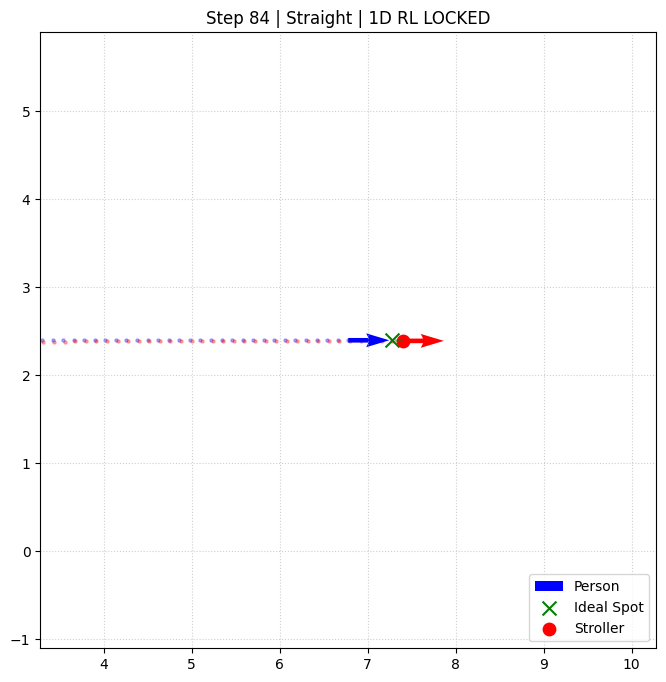

Stopped.


In [ ]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
import numpy as np
import math
import time

# --- INITIAL STATES ---
px, py, p_theta = 0.0, 0.0, math.pi / 2  # Person starts at y=0.0
sx, sy, s_theta = 0.0, 0.5, math.pi / 2  # Cart is 0.5m IN FRONT
p_speed = 1.2

p_trail_x, p_trail_y = [], []
s_trail_x, s_trail_y = [], []

cv_signal = 0
target_dist = 0.5
dt = 0.1
p_state = 0

# New: Flag for the micro-correction module
correction_active = False

print("Starting Vanguard Simulation with Micro-Correction...")
time.sleep(2)

try:
    for step in range(110): # Extended slightly to watch the correction settle
        # ---------------------------------------------------------
        # 1. PERSON SCRIPTED PATH
        # ---------------------------------------------------------
        if step < 20:
            cv_signal = 0

        elif step == 20:
            # Person hits the intersection (y = 2.4) and begins pivot
            cv_signal = 1
            p_state = 1
            p_speed = 0.0

        if p_state == 1:
            # Pivoting 90 degrees Right (East) over 0.5s (5 steps)
            p_theta -= (math.pi / 2) / 5
            if step == 24:
                p_state = 2

        elif p_state == 2:
            # Accelerates back up to walking speed
            cv_signal = 0
            p_speed = min(1.2, p_speed + 1.5 * dt)

        px += p_speed * math.cos(p_theta) * dt
        py += p_speed * math.sin(p_theta) * dt

        # ---------------------------------------------------------
        # 2. CART SCRIPTED PATH
        # ---------------------------------------------------------
        if step < 20:
            # 1D Follow
            s_vel = p_speed
            s_omega = 0.0

        elif 20 <= step < 32:
            # PHASE 1: The Deep Dive (1.2 seconds)
            s_vel = 1.31
            s_omega = -math.pi / 1.2

        elif 32 <= step < 38:
            # PHASE 2: The Left Hook (0.6 seconds)
            s_vel = 1.31
            s_omega = (math.pi / 2) / 0.6
            if step == 37:
                correction_active = True # Activate closed-loop module after macro

        elif step >= 38:
            # PHASE 3: Micro-Correction & 1D P-Controller Sprint

            # --- Linear Velocity Catch-up (Always Active) ---
            # Calculate the ideal X and Y target spots
            ix = px + math.cos(p_theta) * target_dist
            iy = py + math.sin(p_theta) * target_dist

            # Forward error projected along the person's heading
            forward_error = (ix - sx) * math.cos(p_theta) + (iy - sy) * math.sin(p_theta)

            s_vel = p_speed + forward_error * 2.5
            s_vel = np.clip(s_vel, -3.0, 6.0)

            # --- Angular Correction Module ---
            if correction_active:
                # 1. Cross-Track Error (Lateral drift from the person's line)
                cte = -(sx - px) * math.sin(p_theta) + (sy - py) * math.cos(p_theta)

                # 2. Heading Error (Difference in angle)
                heading_error = (s_theta - p_theta + math.pi) % (2 * math.pi) - math.pi

                # Proportional Control Law: Steer against the errors
                s_omega = -2.0 * heading_error - 1.5 * cte

                # Cap the correction turning speed so it doesn't jerk violently
                s_omega = np.clip(s_omega, -1.0, 1.0)

                # Shut down correction if errors are within tight tolerances (1cm and ~1 degree)
                if abs(cte) < 0.01 and abs(heading_error) < 0.02:
                    correction_active = False
            else:
                # 1D RL Takes over: lock steering exactly to the person's heading
                s_theta = p_theta
                s_omega = 0.0

        # --- UNIVERSAL KINEMATICS ENGINE ---
        s_theta += s_omega * dt
        sx += s_vel * math.cos(s_theta) * dt
        sy += s_vel * math.sin(s_theta) * dt

        # ---------------------------------------------------------
        # 3. RENDERING
        # ---------------------------------------------------------
        p_trail_x.append(px); p_trail_y.append(py)
        s_trail_x.append(sx); s_trail_y.append(sy)
        if len(p_trail_x) > 40: p_trail_x.pop(0); p_trail_y.pop(0)
        if len(s_trail_x) > 40: s_trail_x.pop(0); s_trail_y.pop(0)

        # Recalculate ideal spot for rendering
        ix = px + math.cos(p_theta) * target_dist
        iy = py + math.sin(p_theta) * target_dist

        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(8, 8))

        ax.set_xlim(px - 3.5, px + 3.5)
        ax.set_ylim(py - 3.5, py + 3.5)
        ax.set_aspect('equal')

        ax.scatter(p_trail_x, p_trail_y, c='blue', s=5, alpha=0.3)
        ax.scatter(s_trail_x, s_trail_y, c='red', s=5, alpha=0.3)

        ax.quiver(px, py, math.cos(p_theta), math.sin(p_theta), color='blue', scale=15, label='Person')
        ax.scatter(ix, iy, c='green', marker='x', s=100, label='Ideal Spot')

        ax.scatter(sx, sy, c='red', s=80, label='Stroller')
        ax.quiver(sx, sy, math.cos(s_theta), math.sin(s_theta), color='red', scale=15)
        ax.plot([sx, ix], [sy, iy], 'g--', alpha=0.5)

        # Dynamic Status Text
        if step < 38:
            status = "MACRO: S-Curve"
        elif correction_active:
            status = f"ALIGNING (CTE: {cte:.3f}m)"
        else:
            status = "1D RL LOCKED"

        signal_text = "Straight"
        if cv_signal == 1: signal_text = "TURNING RIGHT"

        ax.legend(loc='lower right')
        ax.set_title(f"Step {step} | {signal_text} | {status}")
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.show()

        time.sleep(0.1)

except KeyboardInterrupt:
    print("Stopped.")